# Comprensión de las características para el diseño de entradas en IDS

Ayuda a decidir **qué datos deben introducirse en el modelo IDS (AE + LSTM + CNN)**.

- Analizar la calidad de las características sin procesar (datos faltantes, varianza, correlación, solapamiento)
- Estimar qué características distinguen entre el comportamiento normal y los ataques a un nivel básico
- Crear una tabla transparente de «conservar / revisar / descartar» a partir de señales extraídas exclusivamente del conjunto de datos
- Exportar tablas y gráficos reutilizables para las decisiones de preprocesamiento


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def detect_project_root(start: Path) -> Path:
    """Find the IDS project root robustly from notebook kernels."""
    start = start.resolve()

    def looks_like_ids_root(p: Path) -> bool:
        return (p / "data/processed").exists() and (p / "notebooks").exists() and (p / "src").exists()

    for p in [start, *start.parents]:
        if looks_like_ids_root(p):
            return p

    for p in [start, *start.parents]:
        candidate = p / "ids"
        if looks_like_ids_root(candidate):
            return candidate

    raise FileNotFoundError(
        f"Could not locate IDS project root from cwd={start}. "
        "Expected a directory containing data/processed, notebooks, and src."
    )


ROOT = detect_project_root(Path.cwd())
print(f"Resolved project root: {ROOT}")

DATASET_CONFIGS = {
    "UNSW": {
        "train_path": ROOT / "data/processed/UNSW-NB15/splits/train.csv",
        "val_path": ROOT / "data/processed/UNSW-NB15/splits/validation.csv",
        "test_path": ROOT / "data/processed/UNSW-NB15/splits/test.csv",
        "loader": pd.read_csv,
        "label_col": "attack_cat",
        "normal_label": "Normal",
        "drop_cols": ["attack_cat", "label", "id"],
        "out_fig_dir": ROOT / "reports/figures/unsw/feature_understanding",
        "out_tbl_dir": ROOT / "reports/metrics/unsw/feature_understanding",
    },
    "CIC": {
        "train_path": ROOT / "data/processed/CIC-IDS2017/splits/train/data.parquet",
        "val_path": ROOT / "data/processed/CIC-IDS2017/splits/val/data.parquet",
        "test_path": ROOT / "data/processed/CIC-IDS2017/splits/test/data.parquet",
        "loader": pd.read_parquet,
        "label_col": "attack_type",
        "normal_label": "BENIGN",
        "drop_cols": ["Label", "attack_label", "attack_type", "source_file"],
        "out_fig_dir": ROOT / "reports/figures/cic/feature_understanding",
        "out_tbl_dir": ROOT / "reports/metrics/cic/feature_understanding",
    },
}


def ensure_dirs(cfg: dict) -> None:
    cfg["out_fig_dir"].mkdir(parents=True, exist_ok=True)
    cfg["out_tbl_dir"].mkdir(parents=True, exist_ok=True)


def hist_overlap(a: np.ndarray, b: np.ndarray, bins: int = 40) -> float:
    if len(a) == 0 or len(b) == 0:
        return np.nan
    low = np.nanpercentile(np.concatenate([a, b]), 1)
    high = np.nanpercentile(np.concatenate([a, b]), 99)
    if not np.isfinite(low) or not np.isfinite(high) or low == high:
        return 1.0
    edges = np.linspace(low, high, bins + 1)
    ha, _ = np.histogram(a, bins=edges)
    hb, _ = np.histogram(b, bins=edges)
    pa = ha / max(ha.sum(), 1)
    pb = hb / max(hb.sum(), 1)
    return float(np.minimum(pa, pb).sum())


def single_feature_separability(x: np.ndarray, y: np.ndarray) -> float:
    if np.nanstd(x) == 0:
        return 0.0
    auc = roc_auc_score(y, x)
    return float(abs(auc - 0.5) * 2.0)


print("Dataset-only feature understanding setup ready.")

Resolved project root: /home/freuer/Documents/projects/ai/ids
Dataset-only feature understanding setup ready.


In [2]:
# Choose dataset: "UNSW" or "CIC"
DATASET = "CIC"
assert DATASET in DATASET_CONFIGS, f"Unsupported DATASET={DATASET}"

cfg = DATASET_CONFIGS[DATASET]
ensure_dirs(cfg)

print(f"Dataset: {DATASET}")
print(f"Train file: {cfg['train_path']}")
print(f"Figures out: {cfg['out_fig_dir']}")
print(f"Tables out:  {cfg['out_tbl_dir']}")

Dataset: CIC
Train file: /home/freuer/Documents/projects/ai/ids/data/processed/CIC-IDS2017/splits/train/data.parquet
Figures out: /home/freuer/Documents/projects/ai/ids/reports/figures/cic/feature_understanding
Tables out:  /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding


## Caracteristicas en crudo

El modelo carga la división de datos, separa las etiquetas de las características de entrada de los candidatos y resume la huella numérica y categórica.

Esto determina el tamaño y la complejidad iniciales del espacio de características antes de aplicar cualquier filtro.

In [3]:
train_df = cfg["loader"](cfg["train_path"])
val_df = cfg["loader"](cfg["val_path"])
test_df = cfg["loader"](cfg["test_path"])

label_col = cfg["label_col"]
normal_label = cfg["normal_label"]
drop_cols = cfg["drop_cols"]

X_train = train_df.drop(columns=drop_cols, errors="ignore")
X_val = val_df.drop(columns=drop_cols, errors="ignore")
X_test = test_df.drop(columns=drop_cols, errors="ignore")

y_raw = train_df[label_col]
y_bin = (y_raw != normal_label).astype(int).to_numpy()

raw_numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
raw_categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Train rows: {len(train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}")
print(f"Raw feature count: {X_train.shape[1]}")
print(f"Numeric features: {len(raw_numeric_cols)}")
print(f"Categorical features: {len(raw_categorical_cols)}")

if raw_categorical_cols:
    cat_cardinality = X_train[raw_categorical_cols].nunique(dropna=False).sort_values(ascending=False)
    display(cat_cardinality.head(15).to_frame("unique_values"))

Train rows: 1,619,667 | Val rows: 231,381 | Test rows: 462,762
Raw feature count: 77
Numeric features: 77
Categorical features: 0


- Un gran número de características categóricas o una cardinalidad elevada implican un diseño de codificación más complejo.
- Un gran volumen de datos numéricos con pocas filas aumenta el riesgo de sobreajuste.
- Este inventario define el alcance de las etapas de reducción y priorización que se describen a continuación.

## Redundancia y señales con poca información

Identifica pares de características fuertemente correlacionadas y columnas con baja varianza.

Esto permite identificar las dimensiones de entrada que son redundantes o que probablemente tengan una contribución escasa.

In [4]:
# Correlation and low-variance diagnostics on numeric train features
numeric_df = X_train[raw_numeric_cols].copy()

# Sample large datasets to avoid OOM in correlation matrix O(n * p^2)
MAX_CORR_SAMPLES = 100_000
if len(numeric_df) > MAX_CORR_SAMPLES:
    print(f"Data too large ({len(numeric_df):,} rows), sampling {MAX_CORR_SAMPLES:,} for correlation...")
    corr_df = numeric_df.sample(n=MAX_CORR_SAMPLES, random_state=SEED)
else:
    corr_df = numeric_df

corr = corr_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_rows = []
for col in upper.columns:
    for idx, val in upper[col].dropna().items():
        if val >= 0.90:
            corr_rows.append({"feature_a": idx, "feature_b": col, "abs_corr": float(val)})

high_corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False) if corr_rows else pd.DataFrame(columns=["feature_a", "feature_b", "abs_corr"])

low_var = numeric_df.var().sort_values()
low_var_df = low_var.reset_index()
low_var_df.columns = ["feature", "variance"]

corr_out = cfg["out_tbl_dir"] / "high_correlation_pairs.csv"
var_out = cfg["out_tbl_dir"] / "low_variance_features.csv"
high_corr_df.to_csv(corr_out, index=False)
low_var_df.to_csv(var_out, index=False)

print("Top correlation pairs (>=0.90):")
display(high_corr_df.head(20))
print("Lowest variance features:")
display(low_var_df.head(20))
print(f"Saved: {corr_out}")
print(f"Saved: {var_out}")

Data too large (1,619,667 rows), sampling 100,000 for correlation...
Top correlation pairs (>=0.90):


,feature_a,feature_b,abs_corr
36,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
42,Total Fwd Packets,Subflow Fwd Packets,1.000000
34,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
45,Fwd Packets Length Total,Subflow Fwd Bytes,1.000000
29,RST Flag Count,ECE Flag Count,1.000000
28,Fwd URG Flags,CWE Flag Count,1.000000
27,Fwd PSH Flags,SYN Flag Count,1.000000
47,Total Backward Packets,Subflow Bwd Packets,1.000000
52,Bwd Packets Length Total,Subflow Bwd Bytes,1.000000
43,Total Backward Packets,Subflow Fwd Packets,0.999606


Lowest variance features:


,feature,variance
0,Bwd Avg Bulk Rate,0.000000
1,Bwd Avg Packets/Bulk,0.000000
2,Bwd Avg Bytes/Bulk,0.000000
3,Fwd Avg Bulk Rate,0.000000
4,Fwd Avg Packets/Bulk,0.000000
5,Fwd Avg Bytes/Bulk,0.000000
6,Bwd PSH Flags,0.000000
7,Bwd URG Flags,0.000000
8,CWE Flag Count,0.000009
9,Fwd URG Flags,0.000009


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/high_correlation_pairs.csv
Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/low_variance_features.csv


- Los pares altamente correlacionados son candidatos para la selección agrupada.
- Las características con muy baja varianza suelen poder eliminarse sin pérdida de señal.
- Este bloque reduce el espacio de características antes de la puntuación de estabilidad/separabilidad.

## Correlación

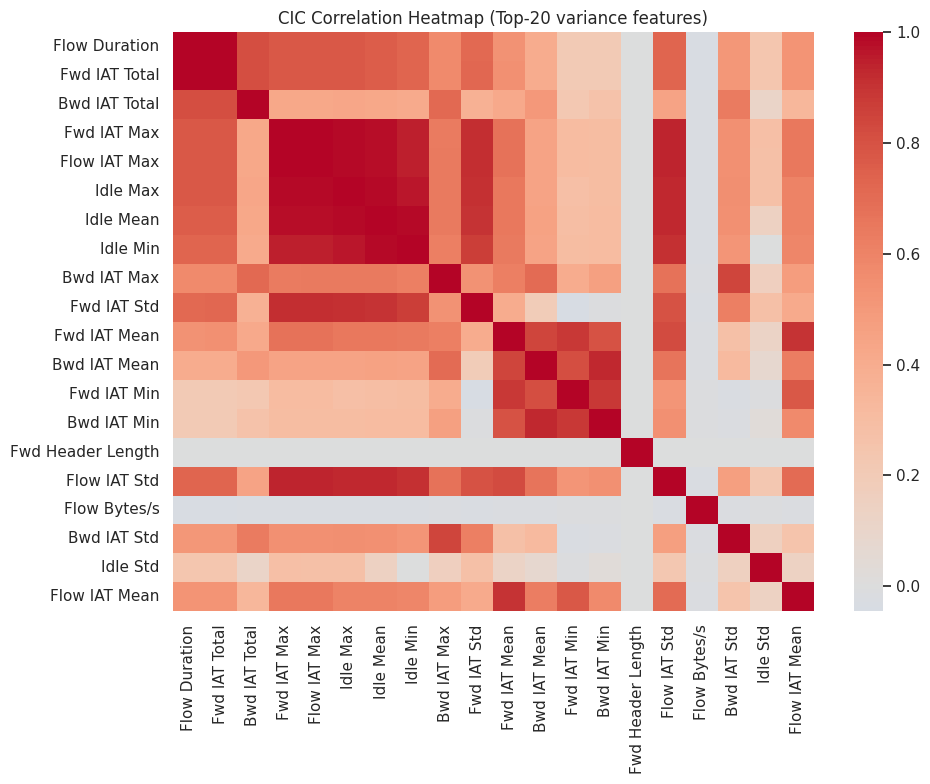

Saved: /home/freuer/Documents/projects/ai/ids/reports/figures/cic/feature_understanding/correlation_heatmap_top20.png


In [ ]:
# Optional quick heatmap using top-20 high variance features
heatmap_features = numeric_df.var().sort_values(ascending=False).head(20).index.tolist()
if heatmap_features:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df[heatmap_features].corr(), cmap="coolwarm", center=0)
    plt.title(f"{DATASET} Correlation Heatmap (Top-20 variance features)")
    plt.tight_layout()
    fig_out = cfg["out_fig_dir"] / "correlation_heatmap_top20.png"
    plt.savefig(fig_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_out}")

- Los bloques densos del mismo color indican grupos con un alto grado de redundancia.
- Selecciona entre uno y dos representantes de cada grupo para el primer contrato.
- Documenta los motivos de la eliminación de características.

## Calidad de las caracteristicas

Implementa estadisticas de calidad por cada caracteristicas

Los indicadores de calidad sirven de guía para las decisiones iniciales de exclusión o revisión antes de proceder a una evaluación más exhaustiva.

In [ ]:
# Data-quality summary table (dataset-only)
missing_ratio = numeric_df.isna().mean()
variance = numeric_df.var()

quality_df = pd.DataFrame(
    {
        "feature": raw_numeric_cols,
        "missing_ratio": [float(missing_ratio.get(f, np.nan)) for f in raw_numeric_cols],
        "variance": [float(variance.get(f, np.nan)) for f in raw_numeric_cols],
    }
)

quality_out = cfg["out_tbl_dir"] / "feature_quality_summary.csv"
quality_df.sort_values(["missing_ratio", "variance"], ascending=[False, True]).to_csv(quality_out, index=False)
display(quality_df.sort_values(["missing_ratio", "variance"], ascending=[False, True]).head(20))
print(f"Saved: {quality_out}")

,feature,missing_ratio,variance
31,Bwd PSH Flags,0.0,0.000000
33,Bwd URG Flags,0.0,0.000000
55,Fwd Avg Bytes/Bulk,0.0,0.000000
56,Fwd Avg Packets/Bulk,0.0,0.000000
57,Fwd Avg Bulk Rate,0.0,0.000000
58,Bwd Avg Bytes/Bulk,0.0,0.000000
59,Bwd Avg Packets/Bulk,0.0,0.000000
60,Bwd Avg Bulk Rate,0.0,0.000000
32,Fwd URG Flags,0.0,0.000009
49,CWE Flag Count,0.0,0.000009


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/feature_quality_summary.csv


- Un alto índice de datos faltantes y una baja varianza son indicadores de que es probable que esos datos deban descartarse.
- Las características de calidad aceptable deben pasar a las comprobaciones de estabilidad y separabilidad.
- Conserva esta tabla como justificación de las decisiones tomadas en la política de preprocesamiento.

## Estabilidad en los splits

Una caracteristica puede parecer sólida en train, pero seguir siendo arriesgada si no se mantiene estable en las divisiones.

In [ ]:
def ks_statistic(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) == 0 or len(b) == 0:
        return np.nan
    a = np.sort(a)
    b = np.sort(b)
    vals = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, vals, side="right") / len(a)
    cdf_b = np.searchsorted(b, vals, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


# Sample large datasets for KS (sort-based, O(n log n) per feature)
MAX_KS_SAMPLES = 200_000
if len(X_train) > MAX_KS_SAMPLES:
    rng = np.random.default_rng(SEED)
    print(f"Data too large ({len(X_train):,} rows), sampling {MAX_KS_SAMPLES:,} for KS stability...")
    X_train_ks = X_train.sample(n=MAX_KS_SAMPLES, random_state=SEED)
    X_val_ks = X_val.sample(n=min(MAX_KS_SAMPLES, len(X_val)), random_state=SEED + 1)
    X_test_ks = X_test.sample(n=min(MAX_KS_SAMPLES, len(X_test)), random_state=SEED + 2)
else:
    X_train_ks, X_val_ks, X_test_ks = X_train, X_val, X_test

stability_rows = []
for feat in raw_numeric_cols:
    tr = X_train_ks[feat].dropna().to_numpy(dtype=float)
    va = X_val_ks[feat].dropna().to_numpy(dtype=float)
    te = X_test_ks[feat].dropna().to_numpy(dtype=float)
    ks_tv = ks_statistic(tr, va)
    ks_tt = ks_statistic(tr, te)
    max_ks = np.nanmax([ks_tv, ks_tt])
    stability_rows.append(
        {
            "feature": feat,
            "ks_train_val": ks_tv,
            "ks_train_test": ks_tt,
            "stability_score": float(1.0 - max_ks) if np.isfinite(max_ks) else np.nan,
        }
    )

stability_df = pd.DataFrame(stability_rows).sort_values("stability_score", ascending=False)
stability_out = cfg["out_tbl_dir"] / "feature_stability_scores.csv"
stability_df.to_csv(stability_out, index=False)

display(stability_df.head(20))
print(f"Saved: {stability_out}")

Data too large (1,619,667 rows), sampling 200,000 for KS stability...


,feature,ks_train_val,ks_train_test,stability_score
55,Fwd Avg Bytes/Bulk,0.000000,0.000000,1.000000
60,Bwd Avg Bulk Rate,0.000000,0.000000,1.000000
31,Bwd PSH Flags,0.000000,0.000000,1.000000
56,Fwd Avg Packets/Bulk,0.000000,0.000000,1.000000
57,Fwd Avg Bulk Rate,0.000000,0.000000,1.000000
58,Bwd Avg Bytes/Bulk,0.000000,0.000000,1.000000
59,Bwd Avg Packets/Bulk,0.000000,0.000000,1.000000
33,Bwd URG Flags,0.000000,0.000000,1.000000
32,Fwd URG Flags,0.000000,0.000005,0.999995
49,CWE Flag Count,0.000000,0.000005,0.999995


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/feature_stability_scores.csv


- Una puntuación alta en estabilidad indica que el comportamiento es coherente en todas las divisiones.
- Una puntuación baja en estabilidad implica que hay que actuar con especial precaución, incluso si la separabilidad es alta.
- Se deben priorizar las características que presenten tanto una buena estabilidad como métricas de calidad aceptables.

## Clusters de redundancia

Agrupa características altamente correlacionadas en clústeres de redundancia ligeros.

Los clústeres ayudan a definir características representativas y a reducir la amplitud de las entradas para la primera iteración del modelo.
ocho clústeres de redundancia.

In [8]:
corr_thr = 0.90
adj = {f: set() for f in raw_numeric_cols}
for _, r in high_corr_df.iterrows():
    a, b, c = r["feature_a"], r["feature_b"], r["abs_corr"]
    if c >= corr_thr:
        adj[a].add(b)
        adj[b].add(a)

visited = set()
clusters = []
for f in raw_numeric_cols:
    if f in visited:
        continue
    stack = [f]
    comp = []
    while stack:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        comp.append(cur)
        stack.extend(list(adj[cur] - visited))
    if len(comp) > 1:
        clusters.append(sorted(comp))

cluster_rows = []
for i, comp in enumerate(sorted(clusters, key=len, reverse=True), 1):
    cluster_rows.append({"cluster_id": i, "size": len(comp), "features": ", ".join(comp)})

cluster_df = pd.DataFrame(cluster_rows)
cluster_out = cfg["out_tbl_dir"] / "feature_redundancy_clusters.csv"
cluster_df.to_csv(cluster_out, index=False)
display(cluster_df.head(20))
print(f"Saved: {cluster_out}")

,cluster_id,size,features
0,1,9,"Avg Bwd Segment Size, Avg Packet Size, Bwd Pac..."
1,2,7,"Flow IAT Max, Flow IAT Std, Fwd IAT Max, Fwd I..."
2,3,6,"Bwd Packets Length Total, Subflow Bwd Bytes, S..."
3,4,3,"Bwd Header Length, Fwd Header Length, Fwd Seg ..."
4,5,2,"Flow Duration, Fwd IAT Total"
5,6,2,"Fwd Packets Length Total, Subflow Fwd Bytes"
6,7,2,"Fwd Packet Length Max, Fwd Packet Length Std"
7,8,2,"Avg Fwd Segment Size, Fwd Packet Length Mean"
8,9,2,"Flow Packets/s, Fwd Packets/s"
9,10,2,"Bwd IAT Mean, Bwd IAT Min"


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/feature_redundancy_clusters.csv


- Los clústeres grandes indican una gran redundancia y son candidatos a la compresión.
- Selecciona valores representativos basándote en la separabilidad, la estabilidad y la calidad.
- Conserva las exportaciones de los clústeres como justificación de las decisiones de poda de características.

## Separabilidad univariante

Calcula en qué medida cada característica numérica distingue entre «Normal» y «Ataque» en los datos de entrenamiento.

Esto proporciona una clasificación preliminar de la prioridad de las señales antes de la importancia de las características basada en el modelo.

In [9]:
# Lightweight separability diagnostics (fast, no heavy feature selectors)
metric_rows = []

for feat in raw_numeric_cols:
    s = X_train[feat].to_numpy(dtype=float)
    if np.nanstd(s) == 0:
        continue

    # Fill NaN only for metric computation
    s_filled = pd.Series(s).fillna(np.nanmedian(s)).to_numpy(dtype=float)
    sep = single_feature_separability(s_filled, y_bin)

    normal_vals = s_filled[y_bin == 0]
    attack_vals = s_filled[y_bin == 1]
    overlap = hist_overlap(normal_vals, attack_vals)

    metric_rows.append(
        {
            "feature": feat,
            "separability_score": sep,
            "class_overlap_score": overlap,
            "variance": float(np.nanvar(s_filled)),
            "missing_ratio": float(np.mean(np.isnan(s))),
        }
    )

metrics_df = pd.DataFrame(metric_rows)
metrics_df = metrics_df.sort_values(["separability_score", "class_overlap_score"], ascending=[False, True])

metrics_out = cfg["out_tbl_dir"] / "feature_lightweight_metrics.csv"
metrics_df.to_csv(metrics_out, index=False)
print(f"Saved: {metrics_out}")
display(metrics_df.head(20))

Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/feature_lightweight_metrics.csv


,feature,separability_score,class_overlap_score,variance,missing_ratio
17,Flow IAT Std,0.124546,0.893581,7.689666e+13,0.0
34,Fwd Packets/s,0.118242,0.981824,1.290692e+10,0.0
22,Fwd IAT Std,0.117813,0.901743,1.108424e+14,0.0
16,Flow IAT Mean,0.113848,0.890667,2.368686e+13,0.0
15,Flow Packets/s,0.113761,0.970382,1.542492e+10,0.0
18,Flow IAT Max,0.110154,0.846513,7.089691e+14,0.0
65,Idle Mean,0.109247,0.897107,6.644729e+14,0.0
35,Bwd Packets/s,0.108796,0.974715,9.079337e+08,0.0
68,Idle Min,0.108772,0.896568,6.508540e+14,0.0
67,Idle Max,0.107881,0.891805,7.060914e+14,0.0


- Una alta separabilidad y un bajo solapamiento indican que las características son buenas candidatas.
- Utiliza la separabilidad junto con la estabilidad y la calidad, no de forma aislada.
- Evita seleccionar características inestables, incluso cuando la separabilidad sea alta.

## Ruta de preprocesamiento

Combina calidad, estabilidad y capacidad de separación en «mantener/revisar/eliminar» y exporta un contrato de preprocesamiento inicial.

In [10]:
# Build keep/review/drop recommendation table and initial contract
reco_df = metrics_df.merge(stability_df[["feature", "stability_score", "ks_train_val", "ks_train_test"]], on="feature", how="left")

reco_df["recommendation"] = "review"
reco_df.loc[
    (reco_df["separability_score"] >= 0.20)
    & (reco_df["class_overlap_score"] <= 0.60)
    & (reco_df["missing_ratio"] <= 0.40)
    & (reco_df["stability_score"] >= 0.70),
    "recommendation",
] = "keep"

reco_df.loc[
    (reco_df["separability_score"] < 0.08)
    | (reco_df["class_overlap_score"] > 0.85)
    | (reco_df["missing_ratio"] > 0.75)
    | (reco_df["variance"] < 1e-8)
    | (reco_df["stability_score"] < 0.40),
    "recommendation",
] = "drop"

# Simple first-pass preprocessing hints
reco_df["impute_hint"] = np.where(reco_df["missing_ratio"] > 0.05, "median", "none")
reco_df["scale_hint"] = np.where(reco_df["variance"] > 0, "robust_scale", "none")
reco_df["log_hint"] = np.where(reco_df["class_overlap_score"] > 0.75, "review_log_transform", "none")
reco_df["encode_hint"] = "numeric"

recommendation_out = cfg["out_tbl_dir"] / "feature_recommendations.csv"
contract_out = cfg["out_tbl_dir"] / "feature_contract_initial.csv"

ordered = reco_df.sort_values(["recommendation", "separability_score", "stability_score"], ascending=[True, False, False])
ordered.to_csv(recommendation_out, index=False)
ordered[[
    "feature",
    "recommendation",
    "separability_score",
    "stability_score",
    "missing_ratio",
    "variance",
    "impute_hint",
    "scale_hint",
    "log_hint",
    "encode_hint",
]].to_csv(contract_out, index=False)

summary = ordered["recommendation"].value_counts().rename_axis("recommendation").reset_index(name="count")
display(summary)
display(ordered.head(30))
print(f"Saved: {recommendation_out}")
print(f"Saved: {contract_out}")

,recommendation,count
0,drop,68
1,review,1


,feature,separability_score,class_overlap_score,variance,missing_ratio,stability_score,ks_train_val,ks_train_test,recommendation,impute_hint,scale_hint,log_hint,encode_hint
0,Flow IAT Std,0.124546,0.893581,7.689666e+13,0.0,0.997140,0.002860,0.002330,drop,none,robust_scale,review_log_transform,numeric
1,Fwd Packets/s,0.118242,0.981824,1.290692e+10,0.0,0.997435,0.002565,0.002395,drop,none,robust_scale,review_log_transform,numeric
2,Fwd IAT Std,0.117813,0.901743,1.108424e+14,0.0,0.997540,0.002460,0.002335,drop,none,robust_scale,review_log_transform,numeric
3,Flow IAT Mean,0.113848,0.890667,2.368686e+13,0.0,0.997170,0.002830,0.002295,drop,none,robust_scale,review_log_transform,numeric
4,Flow Packets/s,0.113761,0.970382,1.542492e+10,0.0,0.997255,0.002745,0.002290,drop,none,robust_scale,review_log_transform,numeric
6,Idle Mean,0.109247,0.897107,6.644729e+14,0.0,0.997745,0.002255,0.001375,drop,none,robust_scale,review_log_transform,numeric
7,Bwd Packets/s,0.108796,0.974715,9.079337e+08,0.0,0.997150,0.002290,0.002850,drop,none,robust_scale,review_log_transform,numeric
8,Idle Min,0.108772,0.896568,6.508540e+14,0.0,0.997520,0.002480,0.001300,drop,none,robust_scale,review_log_transform,numeric
9,Idle Max,0.107881,0.891805,7.060914e+14,0.0,0.997745,0.002255,0.001415,drop,none,robust_scale,review_log_transform,numeric
10,Fwd IAT Max,0.102207,0.900071,7.138288e+14,0.0,0.997095,0.002905,0.001810,drop,none,robust_scale,review_log_transform,numeric


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/feature_recommendations.csv
Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/feature_understanding/feature_contract_initial.csv


- `keep` Candidatos a mantenerse.
- `review` Necesitan procesamiento adicional.
- `feature_contract_initial.csv` is the operational handoff to preprocessing implementation.